In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots 
import time

In [2]:
mulist = np.linspace(0, 3.1, 60)  # μ/U
Jlist = np.linspace(0, 0.1, 50)  # J/U
philist=np.zeros((len(mulist),len(Jlist)), dtype=complex)
U=1.0
Nmax = 50
z=2

maxiter=2000 
tol=1e-6
call_count=0

In [3]:
def buildH(mu,J,phi):
    dim=Nmax+1

    H = np.zeros((dim, dim), dtype=complex)
     
    for n in range(dim):
        H[n, n] = 0.5 * U * n * (n - 1) - mu * n-2*z*J*np.abs(phi)**2
    
    for n in range(Nmax):        
        H[n, n+1] += -2*z*J * np.conj(phi) * np.sqrt(n+1)      
        H[n+1, n] += -2*z*J * phi * np.sqrt(n+1)

    return H

In [4]:
def solveigen(H):
    eigvals, eigvecs = np.linalg.eigh(H)
    
    #eigvals: 一维数组，形状为 (N,)，包含 N 个本征值（按升序排列）

    #eigvecs: 二维数组，形状为 (N, N)，其中每一列是一个本征向量

    # 基态对应最小本征值
    min_index = np.argmin(eigvals)
    psi = eigvecs[:, min_index]
    #energy = eigvals[min_index]

    global call_count
    call_count+=1
    
    return psi


In [5]:
def getphi(psi):

    dim = len(psi)  # =Nmax+1
    phi = 0.0 + 0.0j
    
    for n in range(dim - 1):
        phi += np.conj(psi[n]) * psi[n+1] * np.sqrt(n+1)    
    return phi

In [6]:
def self_consistent(mu,J,phi_ini):
    phi_old=phi_ini

    for itr in range(maxiter):
        H=buildH(mu,J,phi_old)
        psi=solveigen(H)
        phi=getphi(psi)

        diff=np.abs(phi-phi_old)

        if diff < tol:
            #print(f"(J/U={J/U:.3f},μ/U={mu/U:.2f}, ) 收敛，phi: {phi:.2e}")
            return phi
        else:phi_old = 0.7 * phi_old + 0.3 * phi

        if itr==maxiter-1:
            print(f"(J/U={J/U:.3f},μ/U={mu/U:.2f} ) 未能收敛，最终差值diff_phi=: {diff:.2e}")
            return phi

In [7]:
start_time = time.time()
print(f"扫描参数空间: len(X=J)*len(Y=mu)={len(Jlist)}*{len(mulist)} = {len(Jlist)*len(mulist)} 个点")
call_count=0

phi_ini=0.1+0.1j #实测运行2分28秒，对角化259021次     
#在mu/U=整数附近时，往往收敛很慢（超过最大迭代次数），原因是此时系统是SF的（Ep,Eh激发能都为0），phi其实很大
for i in range(len(mulist)):
    for j in range(len(Jlist)):
        J=Jlist[j];mu=mulist[i]

        # if mu<-50*J+3.5:
        #     phi_ini=0.1+0.1j    #先全用phi_ini=0.1+0.1j 算出相图，发现在直线mu=-50*J+3.5右侧的|phi|几乎全大于1，做为初始值加速收敛
        # else:
        #     phi_ini=1/np.sqrt(2)+1/np.sqrt(2)*1j
        #     #确实少对角化了10000次，运行快了10秒


        philist[i][j]=self_consistent(mu,J,phi_ini)

        #phi_ini=philist[i][j] 
        # 想法是把上一组(J,mu)的自洽phi当作下一组的初始，但这会给出全为0.0的输出。
        # 因为 phi=0时的H矩阵=0.5*n*(n-1)-mu*n,基态就是MI极限给出的|n_0>，phi=<b>=sqrt(n_0)*<n_0|n_0-1>恒为0
        # 在很小的J时，自洽收敛到很小的phi（趋于0），如果把它当作下一组参数的初始，就相当于一直把phi=0代入了H，永远会给出<b>=0
end_time = time.time()

run_time=end_time-start_time

print("——"*40)
print(f"全部完成！总耗时 {int(run_time // 60)}分{run_time % 60:.1f} 秒,总共对角化了 {Nmax+1}*{Nmax+1} 矩阵 {call_count}次")

扫描参数空间: len(X=J)*len(Y=mu)=50*60 = 3000 个点
(J/U=0.029,μ/U=0.16 ) 未能收敛，最终差值diff_phi=: 2.22e-05
(J/U=0.041,μ/U=0.32 ) 未能收敛，最终差值diff_phi=: 1.65e-05
(J/U=0.043,μ/U=0.42 ) 未能收敛，最终差值diff_phi=: 3.35e-05
(J/U=0.041,μ/U=0.53 ) 未能收敛，最终差值diff_phi=: 3.74e-05
(J/U=0.039,μ/U=0.58 ) 未能收敛，最终差值diff_phi=: 3.30e-06
(J/U=0.024,μ/U=1.37 ) 未能收敛，最终差值diff_phi=: 4.29e-05
(J/U=0.024,μ/U=1.52 ) 未能收敛，最终差值diff_phi=: 4.59e-06
————————————————————————————————————————————————————————————————————————————————
全部完成！总耗时 3分23.0 秒,总共对角化了 51*51 矩阵 259021次


在μ/U=0.50时，估计的相变点: J_c/U ≈ 0.039
在μ/U=1.50时，估计的相变点: J_c/U ≈ 0.024
在μ/U=2.50时，估计的相变点: J_c/U ≈ 0.016


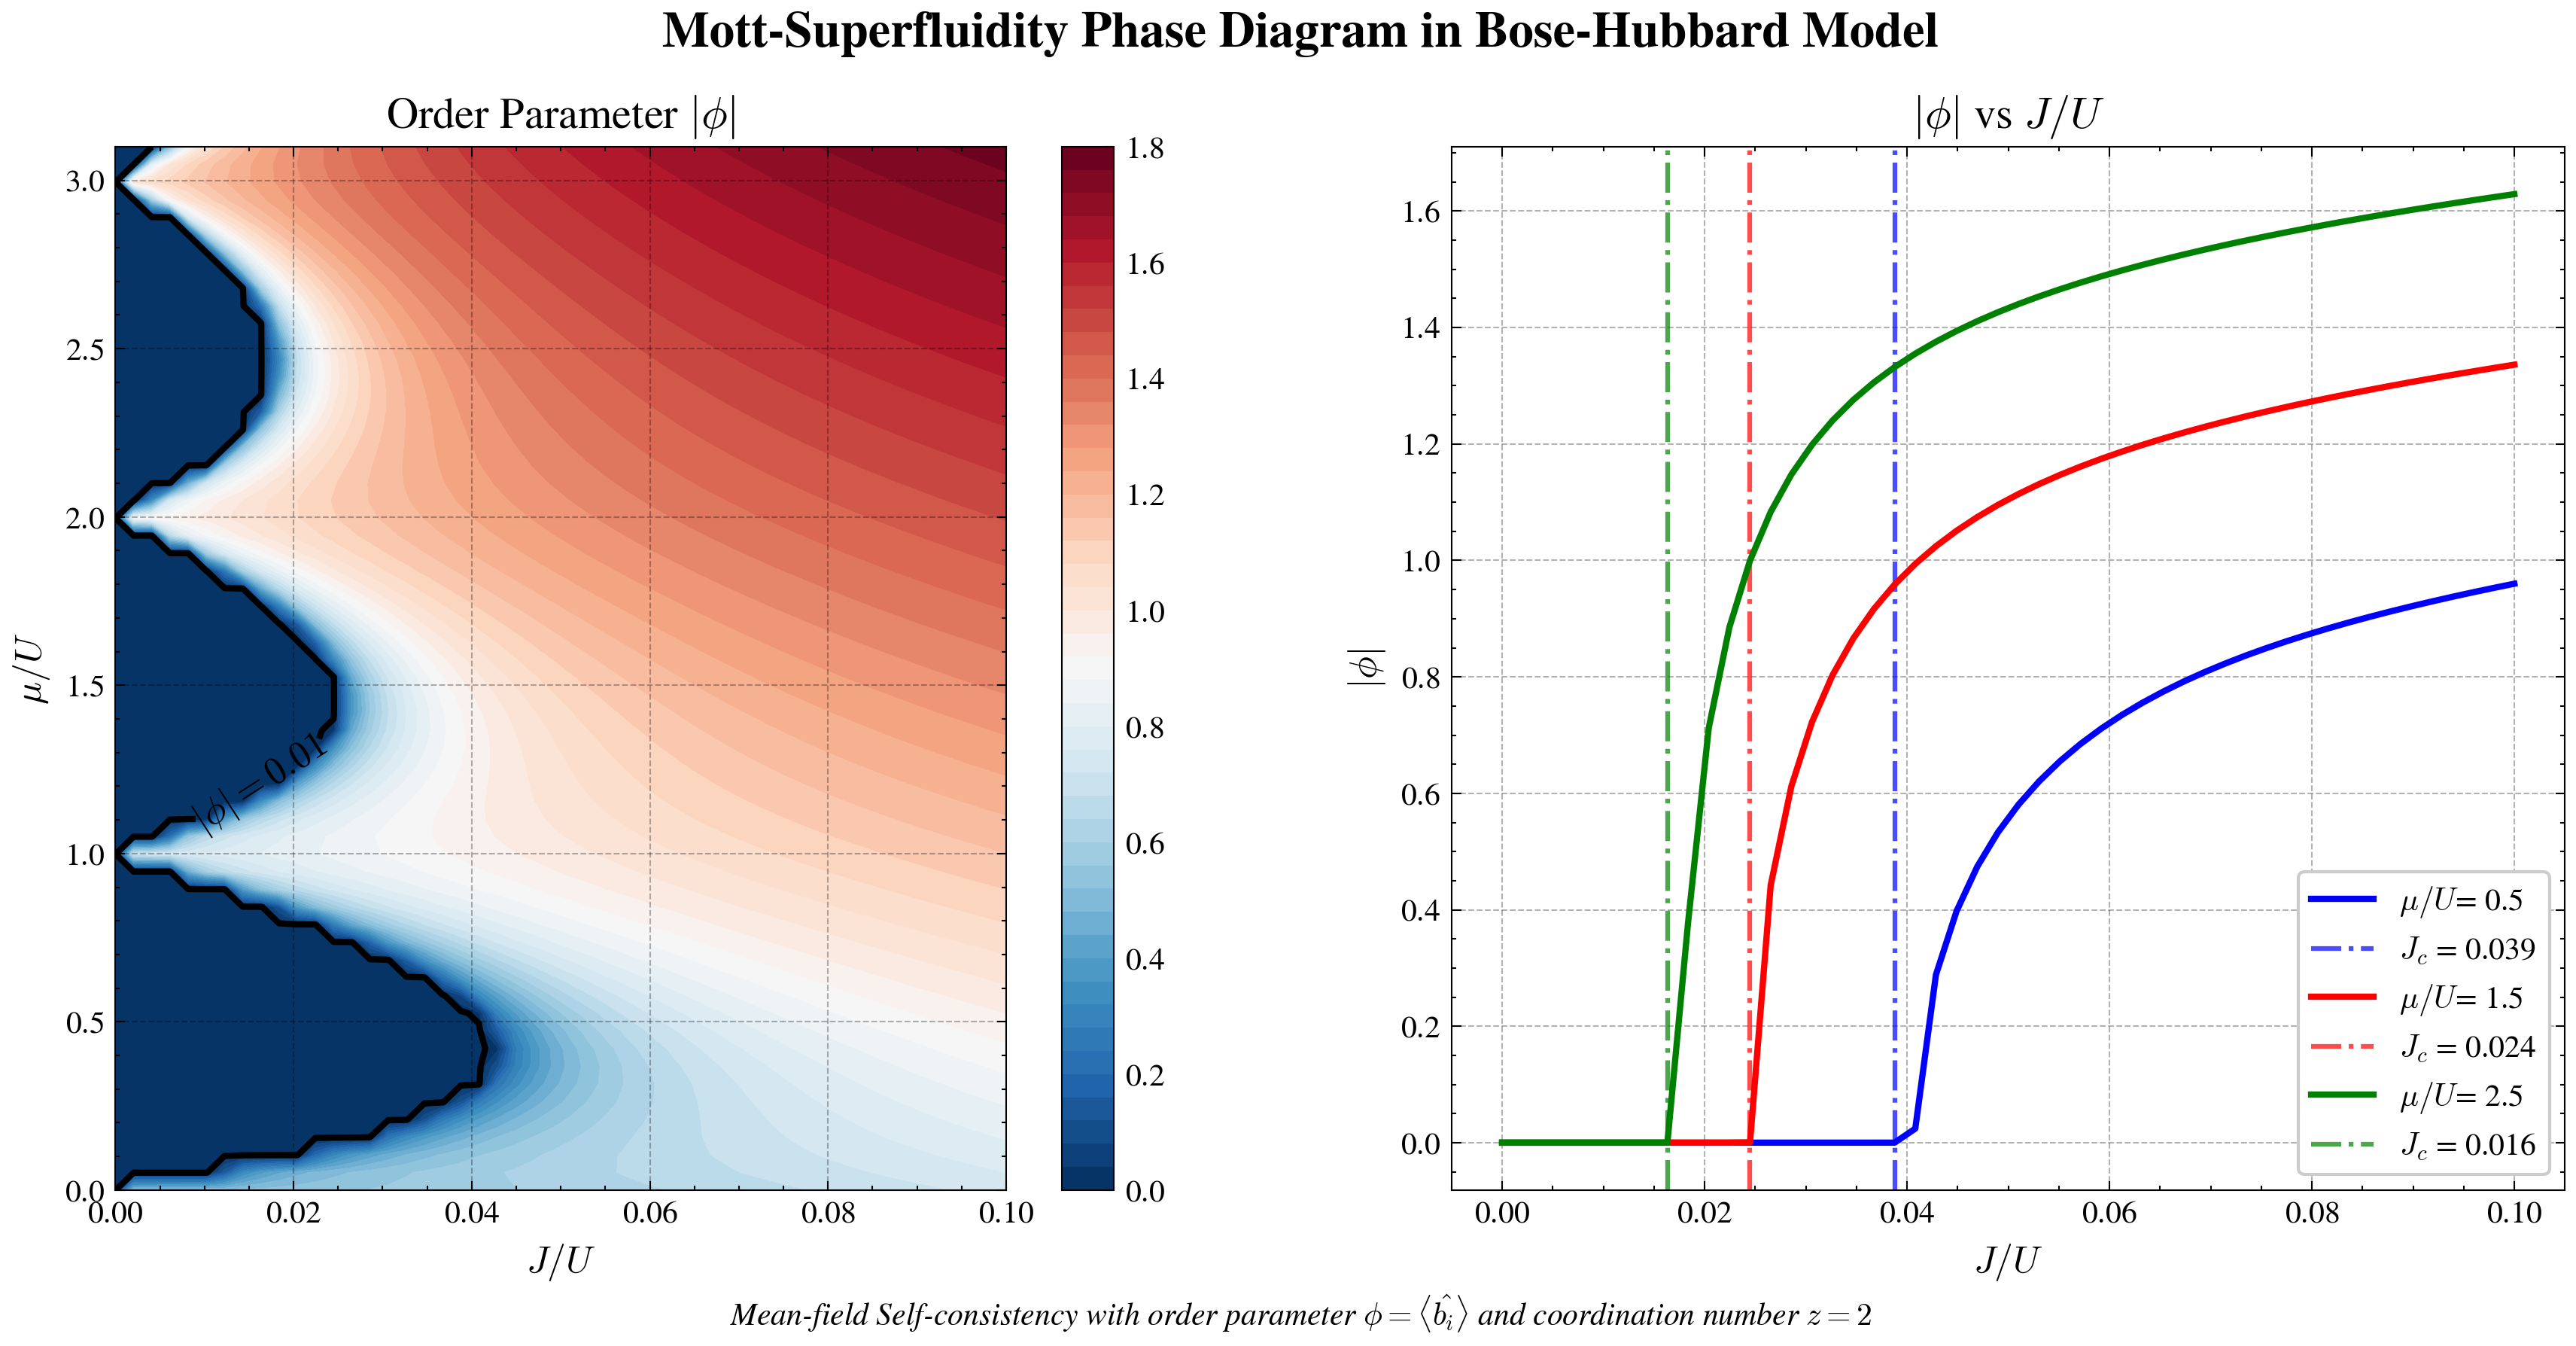

In [8]:
# 创建网格
#meshgrid非常容易闹反顺序!导致报错
J_cord,mu_cord = np.meshgrid(Jlist, mulist) #meshgrid(X,Y),但数组 philist[y(行索引)][x(列索引)],shape=(行数，列数)
with plt.style.context(['science', 'no-latex', 'grid']):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6),dpi=300)

    fig.suptitle('Mott-Superfluidity Phase Diagram in Bose-Hubbard Model', fontsize=16, fontweight='bold', y=0.98)

    im1 = axes[0].contourf(J_cord, mu_cord, np.abs(philist), levels=50, cmap='RdBu_r',zorder=0)#RdBu_r（从蓝到红）

    #contourf(X, Y, Z, ...) 画等值线,只要按上面的数组和索引约定，直接自然写，就不会报错

    axes[0].set_xlabel(r'$J/U$', fontsize=12)
    axes[0].set_ylabel(r'$\mu/U$', fontsize=12)
    axes[0].set_title(r'Order Parameter $|\phi|$', fontsize=14)
    axes[0].grid(True, alpha=0.3,zorder=1)
    plt.colorbar(im1, ax=axes[0])

    # 绘制相边界（|φ|=0.01的等高线）
    C = axes[0].contour(J_cord, mu_cord, np.abs(philist), levels=[0.01], colors="#000000",linewidths=2)
    axes[0].clabel(C, inline=True, fontsize=12, fmt=r'$|\phi|=0.01$')


    # 第二幅子图：固定μ/U时的|φ|随J/U的变化

    mu_fixed = np.array([0.5, 1.5, 2.5])
    colors = ['b', 'r', 'g']  # 为每条线定义不同颜色
    labels = [fr'$\mu/U$= {mu:.1f}' for mu in mu_fixed]

    #f-string (格式化字符串),允许在字符串中直接嵌入表达式，使用 {},
    #r-string (原始字符串),反斜杠 \ 不会理解为转义字符，可以用来输入latex公式
    # fr综合两者
    
    for i, mu in enumerate(mu_fixed):
        # 找到最接近的索引
        idx_mu = np.abs(mulist - mu).argmin()
        
        # 绘制主曲线
        axes[1].plot(Jlist, np.abs(philist[idx_mu, :]), color=colors[i],
                      linewidth=2, label=labels[i])
        
        # 找到相变点（|φ|首次超过阈值）
        philist_fixedmu = np.abs(philist[idx_mu, :])
        phi_threshold = 0.01
        sf_indices = np.where(philist_fixedmu > phi_threshold)[0]

        # 假设 philist_fixedmu = [0, 0.002, 0.005, 0.015, 0.03]
        # philist_fixedmu > 0.01 → [False, False, False, True, True] (Boolean元组)

        #result = np.where(philist_fixedmu > 0.01)
        #print(result)  # 输出: (array([3, 4]),) ← 注意这是个关于索引的元组！除了[3,4]后面为空
        #加[0]取出[3,4]
        
        
        J_c = Jlist[sf_indices[0]-1]      
        #-1是取第一个phi>0.01点最左边的点(最后一个小于等于0.01的），因为J点较少，这两个点突变，画在第一个phi>0.01点显得离相变点太远
        # 绘制相变点竖线，使用与主曲线相同的颜色
        axes[1].axvline(x=J_c, color=colors[i], linestyle='-.', alpha=0.7,linewidth=1.5,
                        label=fr'$J_c$ = {J_c:.3f} ')
        print(f"在μ/U={mu:.2f}时，估计的相变点: J_c/U ≈ {J_c:.3f}")

    # 统一设置第二幅子图的属性
    axes[1].set_xlabel(r'$J/U$', fontsize=12)
    axes[1].set_ylabel(r'$|\phi|$', fontsize=12)
    axes[1].set_title(r'$|\phi|$ vs $J/U$', fontsize=14)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(fontsize=10, loc='best')

    # 调整子图间距，为总标题留出空间
    #plt.tight_layout(rect=[0, 0, 1, 0.96])  # rect=[left, bottom, right, top]
    # 底部注释
    fig.text(0.5, 0.01, 
            r'Mean-field Self-consistency with order parameter $\phi = \langle \hat{b_i} \rangle$ and coordination number $z=2$', 
            ha='center', 
            fontsize=10, 
            style='italic')
    
    plt.show()


